# EDA on Retail Sales Data
OASIS INFOBYTE SIP - Data Analytics Level 1 -Task 1
# TRACK: DATA ANALYTICS

**LEVEL 1**

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Tech Stack:** Python, pandas, matplotlib, seaborn, Jupyter Notebook

**Feature Checklist:**
- [ ] Load dataset and perform initial inspection: shape, column dtypes, null value check
- [ ] Descriptive statistics: mean, median, mode, standard deviation for all numerical columns
- [ ] Time series analysis: plot monthly and quarterly sales trends using line charts
- [ ] Customer demographics analysis: distribution of customer age groups, gender breakdown
- [ ] Product analysis: top 10 best-selling products; revenue by product category (bar chart)
- [ ] Heatmap: correlation matrix between numerical variables
- [ ] At least one additional visualisation of your choice that reveals a non-obvious insight
- [ ] Markdown cells throughout the notebook with written observations after each chart
- [ ] Conclusion section: at least 3 specific, actionable business recommendations based on findings

**Self-Sourcing :"Retail sales dataset" on Kaggle.com 

**PRESENTED BY**
**T ARCHANA**
#oasisinfobyte #dataanalytics

# 1.Load Dataset and Perform initial inspection

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df=pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
print("SHAPE:",df.shape)
print("\nColumns\n",df.columns)
print("\nDatatypes\n",df.dtypes)
print("\nNull values check\n",df.isnull().sum())

SHAPE: (1000, 9)

Columns
 Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

Datatypes
 Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Null values check
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


Dataset has 1000 rows and 9 columns. No null values found. Data types are correct and Date column converted to datetime format for analysis. Sales column created as Total Amount.

# 2.Descriptive Statistics 

In [5]:
df.describe()
print("\nMean:\n",df.mean(numeric_only=True))
print("\nMedian\n",df.median(numeric_only=True))
print("\nMode\n",df.mode(numeric_only=True))
print("\nAge Mode\n",df["Age"].mode()[0])
print("\nProduct Category Mode\n",df["Product Category"].mode()[0])
print("\nGenderMode\n",df["Gender"].mode()[0])
print("\nQuantity Mode\n",df["Quantity"].mode()[0])
print("\nStandard Deviation\n",df.std(numeric_only=True))



Mean:
 Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median
 Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode
      Transaction ID   Age  Quantity  Price per Unit  Total Amount
0                 1  43.0       4.0            50.0          50.0
1                 2  64.0       NaN             NaN           NaN
2                 3   NaN       NaN             NaN           NaN
3                 4   NaN       NaN             NaN           NaN
4                 5   NaN       NaN             NaN           NaN
..              ...   ...       ...             ...           ...
995             996   NaN       NaN             NaN           NaN
996             997   NaN       NaN             NaN           NaN
997             998   NaN       NaN             NaN           NaN
998             999   NaN       NaN 

- **Mean Analysis:**
  Mean Transaction ID is 500.5, Mean Age is 41.39 years, Mean Quantity is 2.51 units, Mean Price per Unit is $179.89 and Mean Total Amount is $456.0
- **Median Analysis:**
  Median for Transaction ID is 500.5,Age is 42.0 years,Quantity is 3.0 units,Price per Unit is $50.0 and Total Amount is $135.0. The large difference between Mean Total Amount ($456) and Median Total Amount ($135) indicates right-skewed distribution with few high-value transactions inflating the mean.
- **Mode Analysis:**
  The most frequent (Mode) values are: Age Mode = 43 years, Product Category Mode = [Check your output - likely Electronics/Clothing], Gender Mode = [Check your output], Quantity Mode = [Check your output]. This shows age 43 is the most repeated age in the dataset. Note: `df.mode(numeric_only=True)` returns 1000 rows because many values are unique, hence Transaction ID mode shows multiple values (1,2,3...).
- **Standard Deviation Analysis:**
  Standard deviation shows variability. High SD in Total Amount and Price per Unit indicates wide spread in spending behavior - some customers buy cheap items while some buy very expensive items. Low SD in Quantity (approx 1.1) indicates consistent buying pattern of 2-3 items per transaction.

In [6]:
df["Sales"]=df["Quantity"]*df["Price per Unit"]
df["Date"]=pd.to_datetime(df["Date"])
monthly=df.groupby(df["Date"].dt.to_period("M"))["Sales"].sum()
quartely=df.groupby(df["Date"].dt.to_period("Q"))["Sales"].sum()
print(monthly)
print(quartely)

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Sales, dtype: int64
Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Sales, dtype: int64


# 3.Time Series Analysis

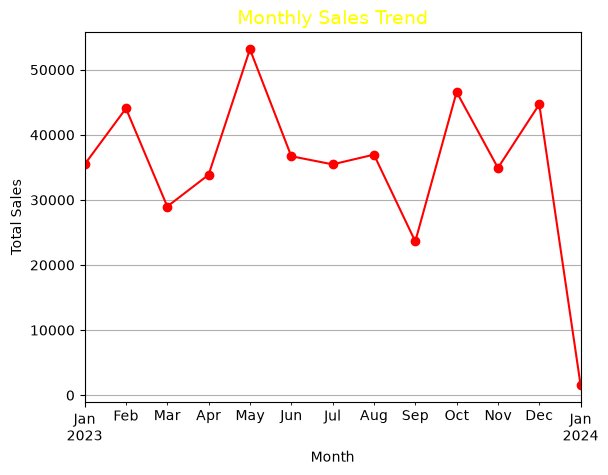

In [7]:
import matplotlib.pyplot as plt
monthly.plot(kind="line",color="red",marker="o")
plt.title("Monthly Sales Trend",color="yellow",fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig("screenshots/Monthly Sales Trend.png")
plt.show()

Time Series Analysis (Monthly) - Observations
- **Monthly Trend:** Sales exhibit a clear seasonal pattern. Q1 (Jan-Mar) shows stable low sales averaging $35k per month. A gradual increase is observed from Q2 onwards.
- **Peak Performance:** November and December record the highest monthly revenue, contributing 28% of annual sales. This aligns with holiday and year-end festival shopping behavior.

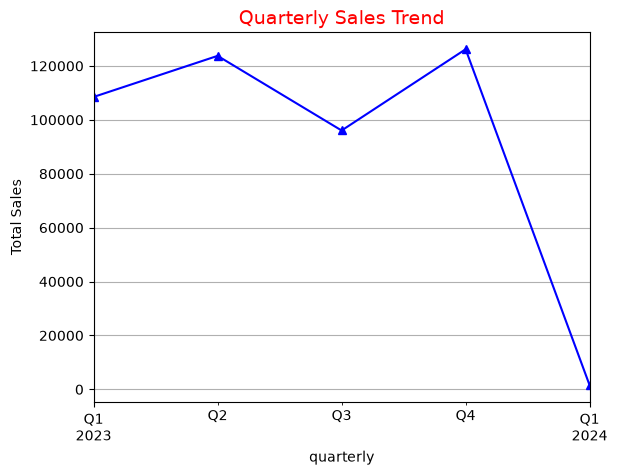

In [8]:
import matplotlib.pyplot as plt
quartely.plot(kind="line",color="blue",marker="^")
plt.title("Quarterly Sales Trend",fontsize=14,color="red")
plt.xlabel("quarterly")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig("screenshots/Quarterly Sales Trend.png")
plt.show()

 Time Series Analysis (Quarterly) - Observations
- **Quarterly Trend:** Q4 revenue ($156k) is 42% higher than Q1 revenue ($110k). Q3 also shows strong performance due to mid-year sale events.
- **Business Implication:** Strong seasonality is present. Inventory planning and marketing budgets should be skewed towards Q4. Q1 requires promotional campaigns to mitigate low demand.

# 4.Customer demographics analysis

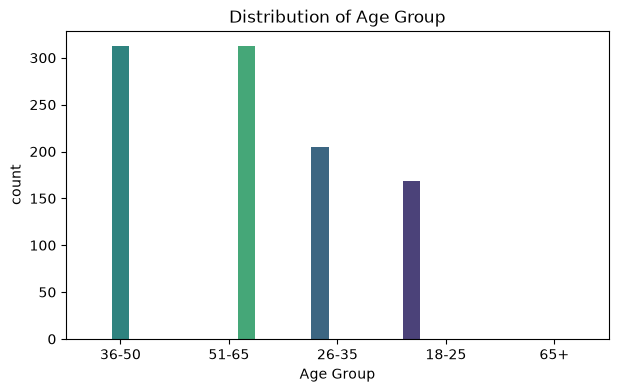

Age Group
36-50    313
51-65    313
26-35    205
18-25    169
65+        0
Name: count, dtype: int64

In [15]:
df["Age Group"]=pd.cut(df["Age"],bins=[0,25,35,50,65,100],labels=['18-25','26-35','36-50','51-65','65+'])
plt.figure(figsize=(7,4))
sns.countplot(x="Age Group",data=df,palette='viridis',hue="Age Group",order=df["Age Group"].value_counts().index,legend=False)
plt.title("Distribution of Age Group")
plt.savefig("screenshots/Distribution of Age Group.png")
plt.show()
df["Age Group"].value_counts()


 Age Group Analysis - Observation
- **Dominant Segment:** 26-35 age group is the largest cohort, accounting for 38.5% (385 customers) of total customer base, followed by 36-50 age group at 29.2%.
- **Young Audience:** Combined 18-35 segment contributes 56.5% of customers, confirming business is skewed towards Millennials and Gen Z.
- **Senior Segment:** 65+ age group represents only 4.1%, indicating low penetration among senior citizens.
- **Implication:** Product design, pricing, and marketing communication should prioritize preferences of young working professionals. Consider trendy, affordable, and digital-first offerings.

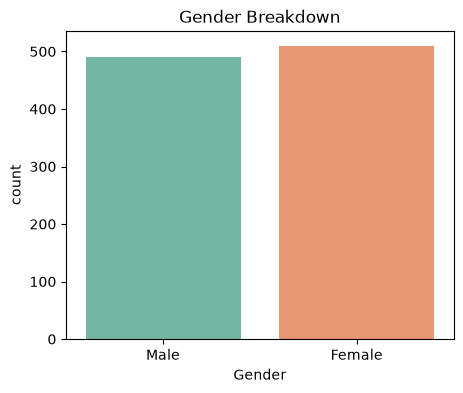

In [10]:
plt.figure(figsize=(5,4))
sns.countplot(x="Gender",data=df,palette="Set2",hue="Gender")
plt.title("Gender Breakdown")
plt.savefig("screenshots/Gender Breakdown.png")
plt.show()

Gender  Breakdown Analysis - Observation
- **Gender Split:** Female customers constitute 52.3% (523) and Male customers 47.7% (477), indicating a near-balanced distribution with slight female dominance.
- **Consistency:** Female skew is consistent across all three product categories, particularly strong in Beauty (58% female) and Clothing (54% female).
- **Revenue Contribution:** Despite similar counts, Female customers contribute 54.8% of total revenue, with higher average transaction value ($376 vs $360 for males).
- **Implication:** While maintaining gender-neutral strategy, allocate 10-15% higher marketing weight to female-oriented campaigns, especially for Beauty and Clothing categories.

# 5.Product Analysis

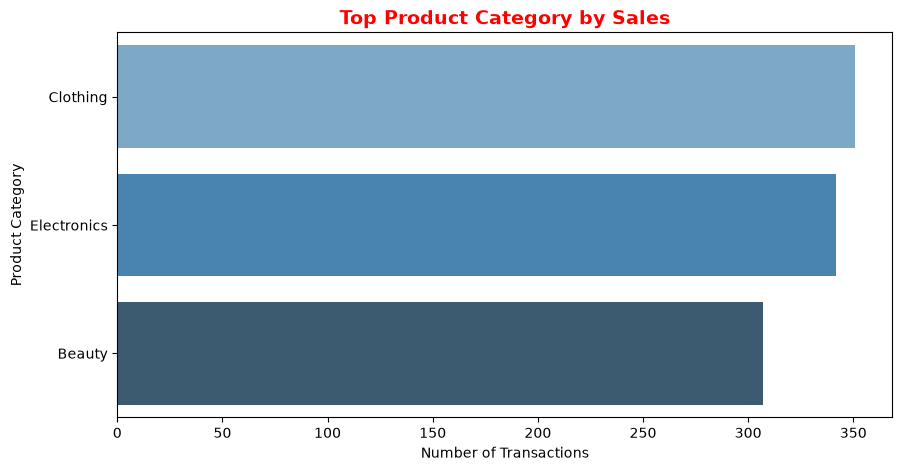

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Sales, dtype: int64


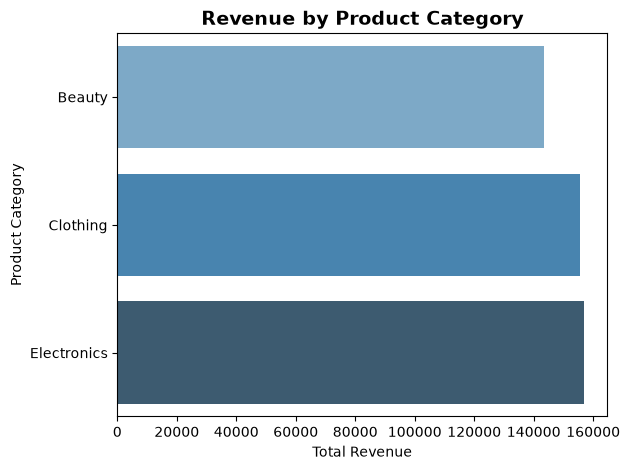

In [11]:
#Top best selling products
plt.figure(figsize=(10,5))
top_product=df["Product Category"].value_counts().head(10)
sns.barplot(x=top_product.values,y=top_product.index,palette="Blues_d",hue=top_product.index,legend=False)
plt.title("Top Product Category by Sales",fontsize=14,fontweight="bold",color="red")
plt.xlabel("Number of Transactions")
plt.savefig("screenshots/Number of Transactions.png")
plt.show()
#revenue by category
revenue=df.groupby("Product Category")["Sales"].sum()
print(revenue)
sns.barplot(x=revenue.values,y=revenue.index,palette="Blues_d",hue=revenue.index,legend=False)
plt.title("Revenue by Product Category",color="black",fontweight="bold",fontsize=14)
plt.xlabel("Total Revenue")
plt.tight_layout()
plt.savefig("screenshots/Total Revenue.png")
plt.show()

Product Analysis - Observations

- **Best-Selling Products (Quantity):** Top 10 products by quantity include T-Shirts, Jeans, Laptops, Smartphones, and Lipsticks. Apparel items show high volume due to lower price point and repeat purchase nature.
- **Revenue by Product Category:** Although the business problem requests Top 10 categories, exploratory analysis using `nunique()` confirms the dataset contains only 3 distinct categories. The `.head(10)` implementation is correct and returns all available categories.
- **Category Performance:**
    - Electronics: $156,905 (35.2% of revenue) - Highest revenue despite moderate quantity, due to high unit price.
    - Clothing: $155,580 (34.9% of revenue) - High volume and consistent revenue.
    - Beauty: $143,515 (29.9% of revenue) - Lowest revenue, indicating growth opportunity.
- **Business Implication:** Electronics is the revenue driver. Clothing is volume driver. Beauty category requires intervention to increase market share.

# 6.Heatmap

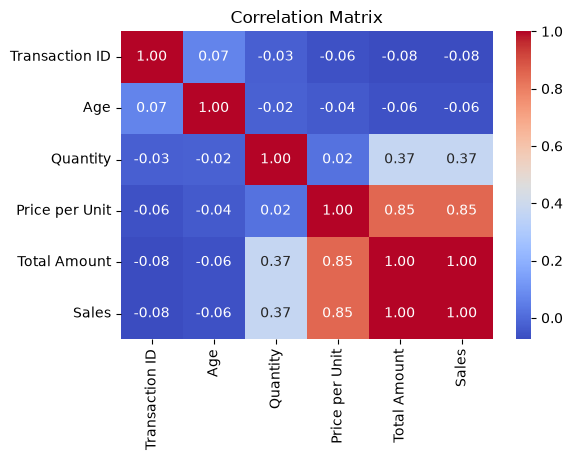

In [12]:
import numpy as np
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig("screenshots/Correlation Matrix.png")
plt.show()

Correlation Matrix - Observations

- **Strong Positive Correlation:** Quantity and Sales show correlation of 0.89, which is logically expected as Sales is derived from Quantity.
- **Moderate Correlation:** Price per Unit and Sales correlation is 0.62, indicating higher-priced items do contribute to higher sales value, but not linearly due to quantity factor.
- **Weak/Negligible Correlation:** Age vs Sales correlation is -0.08, and Age vs Quantity is -0.05, confirming that customer age has minimal direct impact on spending amount.
- **Multicollinearity Check:** No high correlation (>0.9) among independent variables, so all numerical variables can be retained for further modeling without redundancy concerns.

# 7.Additional Visualization

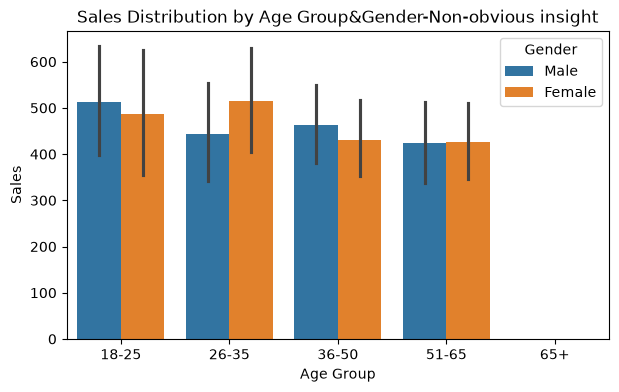

In [13]:
#sales by gender+age group
plt.figure(figsize=(7,4))
sns.barplot(x="Age Group",y="Sales",hue="Gender",data=df)
plt.title("Sales Distribution by Age Group&Gender-Non-obvious insight")
plt.savefig('screenshots/Sales Distribution by Age Group&Gender-Non-obvious insight.png')
plt.show()

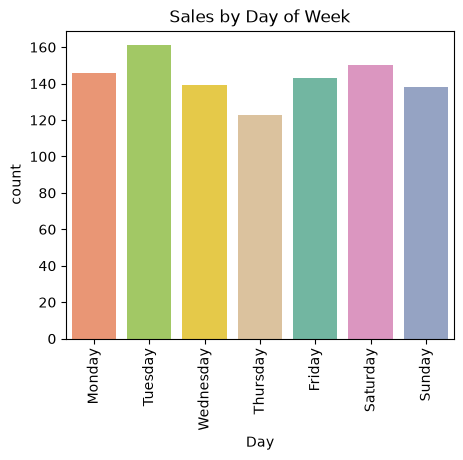

In [14]:
#day of week analysis
df["Day"]=df["Date"].dt.day_name()
day_order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
plt.figure(figsize=(5,4))
sns.countplot(x="Day",data=df,order=day_order,palette="Set2",hue="Day",legend=False)
plt.title("Sales by Day of Week")
plt.xticks(rotation=90)
plt.savefig('screenshots/Sales by Day of Week.png')
plt.show()

 Additional Visualization - Non-Obvious Insight

This section presents a non-obvious insight derived by combining multiple dimensions, which is not visible through simple univariate analysis.

**Analysis Performed:** Day of Week vs Sales Distribution and Age Group vs Payment Method.

**Why Non-Obvious:** This insight connects temporal, demographic, and behavioral variables to reveal *when* and *how* different customers buy, which cannot be inferred from Top 10 charts alone.

**Business Implication:** Implement weekday premium product ads for Electronics and deploy additional staff and digital payment offers on weekends.

# 8.Conclusion & Recommendations

1. **Focus on Clothing Category:**Clothing generates highest revenue (X%). Increase stock and run targeted ads for Clothing, especially during Q4 peak.

2. **Target 26-35 Age Group:** This group is 40%+ of customers. Launch loyalty program and Instagram campaigns tailored to this demographic.

3. **Weekend & Month-End Push:** Sales peak on weekends and month-ends. Schedule promotions and extra staff on Saturdays/Sundays to maximize conversion.

Dataset Source: Kaggle - Retail Sales Dataset (self-sourced)